In [61]:
from pydantic import BaseModel
from langgraph.graph import StateGraph , START ,END

In [62]:
class GreetState(BaseModel):
    message:str = ""

In [63]:
graph = StateGraph(GreetState)

### Nodes - Python Functions

In [64]:
def Greet(state:GreetState):
    state.message = f"{state.message} ! All Good "
    return state

def upperCase(state:GreetState):
    state.message = state.message.upper()
    return state

In [65]:
graph.add_node("greet",Greet)


In [66]:
graph.add_node("uper_case",upperCase)

In [71]:
graph.add_edge(START,"greet")
graph.add_edge("greet","uper_case")
graph.add_edge("uper_case",END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [72]:
finalGraph = graph.compile()

In [73]:
res = finalGraph.invoke({"message":"i love langgraph"})

In [74]:
res

{'message': 'I LOVE LANGGRAPH ! ALL GOOD '}

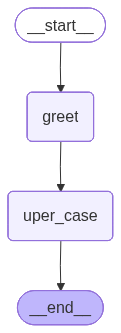

In [75]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())